# 전처리 3단계 — 파생변수: 강우효과 RNE

## 왜 RNE가 필요한가?

> 어제·그제 많은 비가 왔다면 숲이 촉촉해서 산불이 잘 안 납니다.  
> RNE(Rain Effect)는 **최근 3일의 강수량이 산불 위험을 얼마나 낮추는지**를 수치로 표현합니다.
>
> - RNE = 1.0 → 최근 3일 비 없음 → 산불 위험 그대로
> - RNE = 0.1 → 최근 3일 폭우 → 산불 위험 90% 감소

## 계산 방법 (2단계)

### 1단계: 강수 등급 분류
| 일강수량 | 등급(RN) |
|---------|----------|
| 0 ~ 1mm 미만 | 0 |
| 1 ~ 5mm 미만 | 1 |
| 5 ~ 10mm 미만 | 2 |
| 10mm 이상 | 3 |

### 2단계: RNE_Temp → RNE 변환
```
RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
```
| RNE_Temp | RNE (강우효과) |
|----------|---------------|
| 0 ~ 1 | 1.0 (비 효과 없음) |
| 1 ~ 2 | 1.0 |
| 2 ~ 3 | 0.5 |
| 3 ~ 4 | 0.4 |
| 4 ~ 5 | 0.3 |
| 5 ~ 6 | 0.2 |
| 6 이상 | 0.1 (비 효과 최대) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_PATH   = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
SCALED_PATH = os.path.join(BASE_PATH, 'weather_scaled')
OUTPUT_PATH = os.path.join(BASE_PATH, 'derived')
MONTHS      = ['2025-02', '2025-03', '2025-04', '2025-05']

# 등급 분류 기준
RN_BINS   = [0, 1, 5, 10, np.inf]
RN_LABELS = [0, 1, 2, 3]

# RNE_Temp → RNE 매핑
def rne_from_temp(temp_series):
    conditions = [
        temp_series < 2,
        temp_series < 3,
        temp_series < 4,
        temp_series < 5,
        temp_series < 6,
    ]
    choices = [1.0, 0.5, 0.4, 0.3, 0.2]
    return np.select(conditions, choices, default=0.1).astype('float32')

os.makedirs(OUTPUT_PATH, exist_ok=True)
print('설정 완료')

설정 완료


---
## Step 1. 계산 예시 확인

In [2]:
test = pd.DataFrame({
    'grid_id':    ['A']*6,
    'date':       pd.date_range('2025-03-01', periods=6),
    'rn_day_mean':[0.0, 0.5, 3.0, 12.0, 7.5, 0.0]
})

test['rn_class']  = pd.cut(test['rn_day_mean'], bins=RN_BINS, labels=RN_LABELS, right=False).astype(int)
test['rn_class1'] = test.groupby('grid_id')['rn_class'].shift(1).fillna(0).astype(int)
test['rn_class2'] = test.groupby('grid_id')['rn_class'].shift(2).fillna(0).astype(int)
test['rne_temp']  = test['rn_class2'] + test['rn_class1'] + test['rn_class']
test['rne']       = rne_from_temp(test['rne_temp'])

print('=== 계산 예시 ===')
print(test[['date','rn_day_mean','rn_class','rn_class1','rn_class2','rne_temp','rne']].to_string(index=False))
print()
print('해석:')
print('  - 1~2일: 비 없음 -> RNE=1.0 (위험 감소 없음)')
print('  - 4~5일: 연속 비 -> RNE가 낮아져 산불 위험 감소')
print('  - 6일:   오늘 비 없지만 어제·그제 비가 있었으므로 RNE<1.0')

=== 계산 예시 ===
      date  rn_day_mean  rn_class  rn_class1  rn_class2  rne_temp  rne
2025-03-01          0.0         0          0          0         0  1.0
2025-03-02          0.5         0          0          0         0  1.0
2025-03-03          3.0         1          0          0         1  1.0
2025-03-04         12.0         3          1          0         4  0.3
2025-03-05          7.5         2          3          1         6  0.1
2025-03-06          0.0         0          2          3         5  0.2

해석:
  - 1~2일: 비 없음 -> RNE=1.0 (위험 감소 없음)
  - 4~5일: 연속 비 -> RNE가 낮아져 산불 위험 감소
  - 6일:   오늘 비 없지만 어제·그제 비가 있었으므로 RNE<1.0


---
## Step 2. 전체 데이터 RNE 계산 (월별 + 2일 버퍼 이월)

In [3]:
start_total = time.time()
buffer   = None
LAG_DAYS = 2

for m in MONTHS:
    t0 = time.time()
    print(f'[{m}] 읽기...', end=' ', flush=True)

    df_m = pd.read_parquet(
        SCALED_PATH,
        filters=[('month', '==', m)],
        columns=['grid_id', 'date', 'rn_day_mean']
    )

    # 버퍼(이전 달 마지막 2일) 붙이기
    if buffer is not None:
        df_m = pd.concat([buffer, df_m], ignore_index=True)

    df_m = df_m.sort_values(['grid_id', 'date']).reset_index(drop=True)

    # 강수 등급 분류
    df_m['rn_class'] = pd.cut(
        df_m['rn_day_mean'],
        bins=RN_BINS, labels=RN_LABELS, right=False
    ).astype('int8')

    # 1일전, 2일전 lag (이전 달 첫날은 0으로 채움)
    grp = df_m.groupby('grid_id')['rn_class']
    df_m['rn_class1'] = grp.shift(1).fillna(0).astype('int8')
    df_m['rn_class2'] = grp.shift(2).fillna(0).astype('int8')

    # RNE_Temp 합산 & RNE 매핑
    df_m['rne_temp'] = (df_m['rn_class2'] + df_m['rn_class1'] + df_m['rn_class']).astype('int8')
    df_m['rne']      = rne_from_temp(df_m['rne_temp'])

    # 버퍼 행 제거
    month_start = pd.Timestamp(m + '-01')
    df_result   = df_m[df_m['date'] >= month_start].copy()

    # 다음 달 버퍼 저장 (마지막 2일)
    last_2 = sorted(df_result['date'].unique())[-LAG_DAYS:]
    buffer  = df_result[df_result['date'].isin(last_2)][['grid_id','date','rn_day_mean']].copy()

    # 저장
    out_dir = os.path.join(OUTPUT_PATH, 'rne', f'month={m}')
    os.makedirs(out_dir, exist_ok=True)
    df_result[['grid_id','date','rn_class','rne_temp','rne']].to_parquet(
        os.path.join(out_dir, 'data.parquet'),
        index=False, engine='pyarrow', compression='snappy'
    )

    elapsed = time.time() - t0
    rne1_pct = (df_result['rne'] == 1.0).mean() * 100
    print(f'{len(df_result):,}행, RNE=1.0비율:{rne1_pct:.1f}%, {elapsed:.1f}초')

print(f'\n전체 완료: {time.time()-start_total:.1f}초')

[2025-02] 읽기... 7,644,028행, RNE=1.0비율:100.0%, 7.4초
[2025-03] 읽기... 8,463,031행, RNE=1.0비율:92.0%, 8.9초
[2025-04] 읽기... 8,190,030행, RNE=1.0비율:81.5%, 7.5초
[2025-05] 읽기... 8,463,031행, RNE=1.0비율:71.3%, 7.6초

전체 완료: 31.5초


---
## Step 3. 결과 검증

> **검증 포인트**:  
> 1. RNE 값이 [0.1, 0.2, 0.3, 0.4, 0.5, 1.0] 6가지만 존재하는가?  
> 2. RNE=1.0 (비 없는 날)이 가장 많은가? (강수 없는 날이 90%+)  
> 3. 실제 비가 온 날에 RNE가 내려가는가?

In [4]:
RNE_PATH = os.path.join(OUTPUT_PATH, 'rne')

print('=== 월별 RNE 분포 ===')
for m in MONTHS:
    df = pd.read_parquet(RNE_PATH, filters=[('month','==',m)])
    vc = df['rne'].value_counts().sort_index()
    total = len(df)
    print(f'\n[{m}] 총 {total:,}행')
    for v, cnt in vc.items():
        bar = '|' * int(cnt/total*50)
        print(f'  RNE={v:.1f}: {cnt:>10,}건 ({cnt/total*100:5.1f}%) {bar}')

=== 월별 RNE 분포 ===

[2025-02] 총 7,644,028행
  RNE=1.0:  7,644,028건 (100.0%) ||||||||||||||||||||||||||||||||||||||||||||||||||

[2025-03] 총 8,463,031행
  RNE=0.1:      3,978건 (  0.0%) 
  RNE=0.2:     19,718건 (  0.2%) 
  RNE=0.3:    113,925건 (  1.3%) 
  RNE=0.4:    226,192건 (  2.7%) |
  RNE=0.5:    315,310건 (  3.7%) |
  RNE=1.0:  7,783,908건 ( 92.0%) |||||||||||||||||||||||||||||||||||||||||||||

[2025-04] 총 8,190,030행
  RNE=0.2:      8,300건 (  0.1%) 
  RNE=0.3:    128,113건 (  1.6%) 
  RNE=0.4:    502,225건 (  6.1%) |||
  RNE=0.5:    880,030건 ( 10.7%) |||||
  RNE=1.0:  6,671,362건 ( 81.5%) ||||||||||||||||||||||||||||||||||||||||

[2025-05] 총 8,463,031행
  RNE=0.1:     13,166건 (  0.2%) 
  RNE=0.2:     83,543건 (  1.0%) 
  RNE=0.3:    254,207건 (  3.0%) |
  RNE=0.4:    641,401건 (  7.6%) |||
  RNE=0.5:  1,433,755건 ( 16.9%) ||||||||
  RNE=1.0:  6,036,959건 ( 71.3%) |||||||||||||||||||||||||||||||||||


In [5]:
# 강수 있는 날 RNE 변화 추적 (샘플 격자)
df_rne = pd.read_parquet(RNE_PATH)
df_rn  = pd.read_parquet(SCALED_PATH, columns=['grid_id','date','rn_day_mean'])

# 비가 가장 많이 온 격자-날짜 찾기
df_merged = df_rne.merge(df_rn, on=['grid_id','date'])

# 비가 온 날이 여러 번 있는 격자 선택
rainy_grids = df_merged[df_merged['rn_day_mean'] >= 5].groupby('grid_id')['date'].count()
target_grid = rainy_grids.idxmax()
print(f'검증 격자: {target_grid} (비 5mm+ 날 {rainy_grids.max()}일)')

df_grid = df_merged[df_merged['grid_id']==target_grid].sort_values('date')

# 비가 온 날 전후 5일 윈도우 출력
rainy_days = df_grid[df_grid['rn_day_mean'] >= 5]['date'].values
if len(rainy_days) > 0:
    pivot_date = pd.Timestamp(rainy_days[len(rainy_days)//2])
    window = pd.date_range(pivot_date - pd.Timedelta(days=2),
                           pivot_date + pd.Timedelta(days=4))
    df_show = df_grid[df_grid['date'].isin(window)]
    print(df_show[['date','rn_day_mean','rn_class','rne_temp','rne']].to_string(index=False))
    print()
    print('해석: 비가 오면 rn_class가 올라가고, 다음날부터 rne_temp가 높아져 rne가 낮아짐')

검증 격자: 10162_19643 (비 5mm+ 날 11일)
      date  rn_day_mean  rn_class  rne_temp  rne
2025-05-01       5.6250         2         2  0.5
2025-05-02       1.6375         1         3  0.4
2025-05-03       5.5250         2         5  0.2
2025-05-04       0.9250         0         3  0.4
2025-05-05       0.0000         0         2  0.5
2025-05-06       0.0000         0         0  1.0
2025-05-07       0.0000         0         0  1.0

해석: 비가 오면 rn_class가 올라가고, 다음날부터 rne_temp가 높아져 rne가 낮아짐


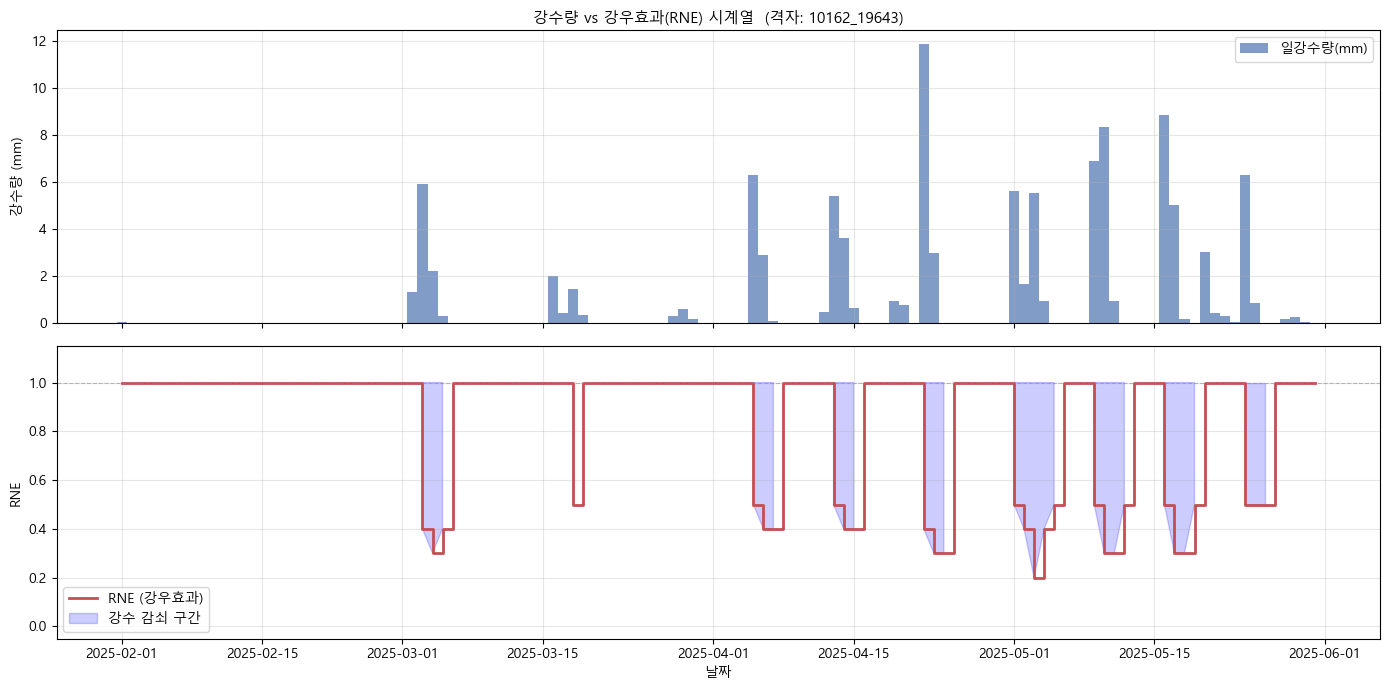

In [6]:
# 시각화: 강수량 vs RNE 시계열
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.bar(df_grid['date'], df_grid['rn_day_mean'],
        color='#4C72B0', alpha=0.7, width=1, label='일강수량(mm)')
ax1.set_ylabel('강수량 (mm)')
ax1.set_title(f'강수량 vs 강우효과(RNE) 시계열  (격자: {target_grid})', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.step(df_grid['date'], df_grid['rne'], color='#C44E52',
         linewidth=2, where='post', label='RNE (강우효과)')
ax2.set_ylim(-0.05, 1.15)
ax2.set_ylabel('RNE')
ax2.set_xlabel('날짜')
ax2.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.fill_between(df_grid['date'], df_grid['rne'], 1.0,
                 where=(df_grid['rne'] < 1.0),
                 alpha=0.2, color='blue', label='강수 감쇠 구간')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'PREP_03_RNE시계열.png'), dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# 월별 요약 통계
print('=== 월별 RNE 요약 ===')
print(f'{"월":<12} {"RNE=1.0":>10} {"RNE<1.0":>10} {"RNE=0.1(최저)":>14}')
print('-' * 52)
for m in MONTHS:
    df = pd.read_parquet(RNE_PATH, filters=[('month','==',m)])
    total = len(df)
    r1  = (df['rne'] == 1.0).sum() / total * 100
    rlt = (df['rne'] <  1.0).sum() / total * 100
    r01 = (df['rne'] == 0.1).sum() / total * 100
    print(f'{m:<12} {r1:>9.1f}% {rlt:>9.1f}% {r01:>13.2f}%')

print()
print('RNE=1.0 : 최근 3일 비 없음 → 산불 위험 감쇠 없음')
print('RNE<1.0 : 최근 3일 안에 비가 있었음 → 위험 감소')
print('RNE=0.1 : 최근 3일 연속 폭우 → 위험 90% 감소')

=== 월별 RNE 요약 ===
월               RNE=1.0    RNE<1.0    RNE=0.1(최저)
----------------------------------------------------
2025-02          100.0%       0.0%          0.00%
2025-03           92.0%       8.0%          0.00%
2025-04           81.5%      18.5%          0.00%
2025-05           71.3%      28.7%          0.00%

RNE=1.0 : 최근 3일 비 없음 → 산불 위험 감쇠 없음
RNE<1.0 : 최근 3일 안에 비가 있었음 → 위험 감소
RNE=0.1 : 최근 3일 연속 폭우 → 위험 90% 감소


---
## 최종 요약

In [8]:
print('=' * 55)
print('  파생변수 2: 강우효과 RNE 생성 완료')
print('=' * 55)
print('''
  공식
  RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
  등급: <1mm=0, 1~5mm=1, 5~10mm=2, 10mm+=3

  저장 컬럼
  - rn_class  : 당일 강수 등급 (0~3)
  - rne_temp  : 3일 강수 등급 합산 (0~9)
  - rne       : 최종 강우효과 (0.1~1.0)

  저장 위치
  - derived/rne/ (월별 파티션)

  DWI 공식에서의 역할
  DWI = PreDWI_등급 × RNE
  -> RNE=1.0 : 비 없음, PreDWI 그대로 반영
  -> RNE=0.1 : 폭우 지속, PreDWI를 90% 감소

  다음 단계
  - 파생변수 3: 일 가중치 (w_d)
    월/일 기준 산불 위험 계절 가중치
''')
print('=' * 55)

  파생변수 2: 강우효과 RNE 생성 완료

  공식
  RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
  등급: <1mm=0, 1~5mm=1, 5~10mm=2, 10mm+=3

  저장 컬럼
  - rn_class  : 당일 강수 등급 (0~3)
  - rne_temp  : 3일 강수 등급 합산 (0~9)
  - rne       : 최종 강우효과 (0.1~1.0)

  저장 위치
  - derived/rne/ (월별 파티션)

  DWI 공식에서의 역할
  DWI = PreDWI_등급 × RNE
  -> RNE=1.0 : 비 없음, PreDWI 그대로 반영
  -> RNE=0.1 : 폭우 지속, PreDWI를 90% 감소

  다음 단계
  - 파생변수 3: 일 가중치 (w_d)
    월/일 기준 산불 위험 계절 가중치

